### Load the Dataset & Clean Missing Values
This cell automatically locates marketing data file, explores its shape, and handles any missing values cleanly.

In [1]:
import os
import pandas as pd

# Look for the dataset under its platform name or your local uploaded name
if os.path.exists("marketing_and_sales_data_evaluate_lr.csv"):
    file_path = "marketing_and_sales_data_evaluate_lr.csv"
elif os.path.exists("85334965-5736-457a-b8d4-a077e6872f84.csv"):
    file_path = "85334965-5736-457a-b8d4-a077e6872f84.csv"
else:
    file_path = "marketing_and_sales_data_evaluate_lr.csv"

# Load the data into a Pandas DataFrame
df = pd.read_csv(file_path)

# Explore missing values before cleaning
print("Missing Values Count Before Cleaning")
print(df.isnull().sum())

# Handle missing values by dropping them
df = df.dropna()

# Verify the clean dataset structure
print("\nCleaned DataFrame Info")
print(df.info())
df.head()

Missing Values Count Before Cleaning
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Cleaned DataFrame Info
<class 'pandas.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4546 non-null   float64
 1   Radio         4546 non-null   float64
 2   Social_Media  4546 non-null   float64
 3   Sales         4546 non-null   float64
dtypes: float64(4)
memory usage: 177.6 KB
None


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


### Exploratory Data Analysis (EDA) & Correlation Analysis
This cell calculates the correlations to identify which platform (TV, Radio, or Social Media) has the highest linear correlation with Sales.

Correlation Matrix
                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000

The variable most highly correlated with Sales is: TV (r = 0.9995)


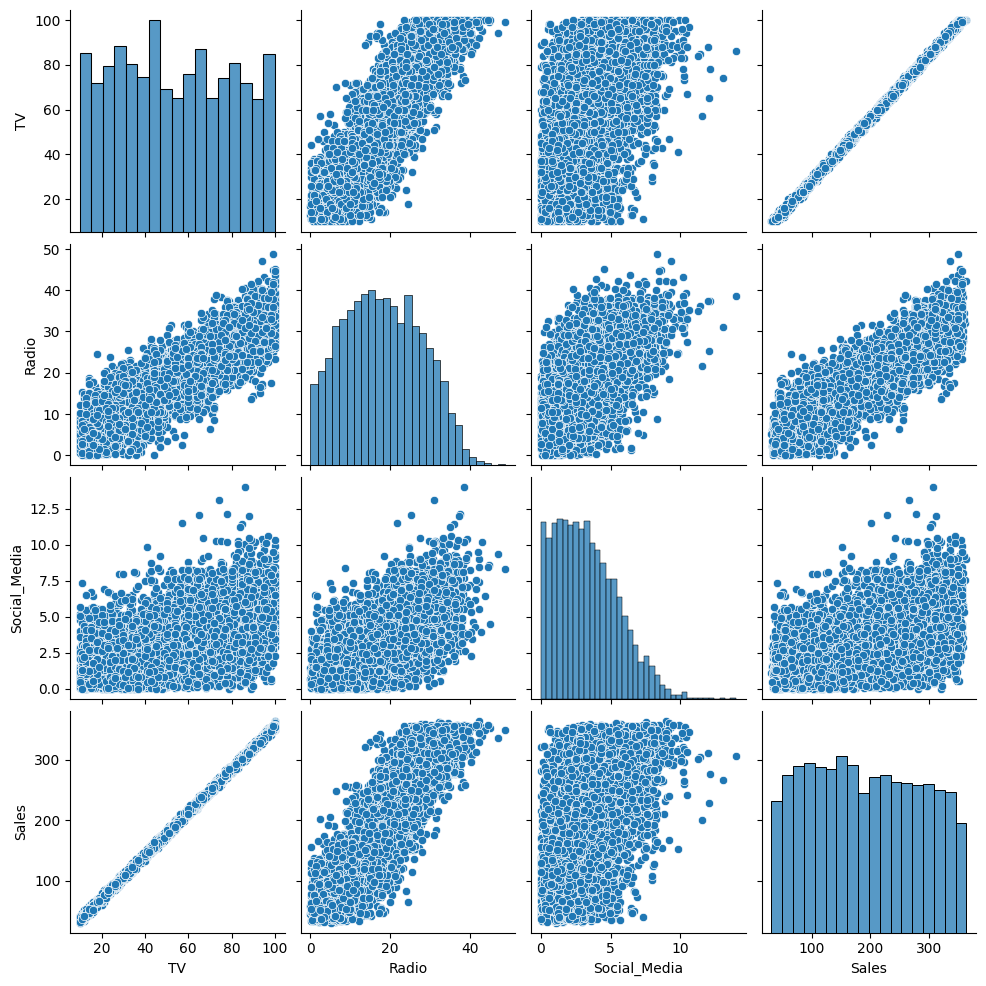

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = df.corr()
print("Correlation Matrix")
print(correlation_matrix)

# Identify the independent variable with the highest correlation to Sales
highest_corr_var = correlation_matrix['Sales'].drop('Sales').idxmax()
highest_corr_val = correlation_matrix['Sales'].drop('Sales').max()
print(f"\nThe variable most highly correlated with Sales is: {highest_corr_var} (r = {highest_corr_val:.4f})")

# Display the pairplot directly down the cell
sns.pairplot(df)
plt.show()

### Build the OLS Regression Model
Using statsmodels, this cell adds a constant and fits a Ordinary Least Squares (OLS) simple linear regression model where TV predicts Sales.

In [3]:
import statsmodels.api as sm

# Define independent (X) and dependent (y) variables
X = df['TV']
y = df['Sales']

# Add a constant link to include the intercept term
X = sm.add_constant(X)

# Fit the Ordinary Least Squares model
model = sm.OLS(y, X).fit()

# Print the summary output for interpretation
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:26:10   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

### Create Model Diagnostic Plots
This step validates the key regression assumptions (Linearity, Normality, and Homoscedasticity) using residual plots.

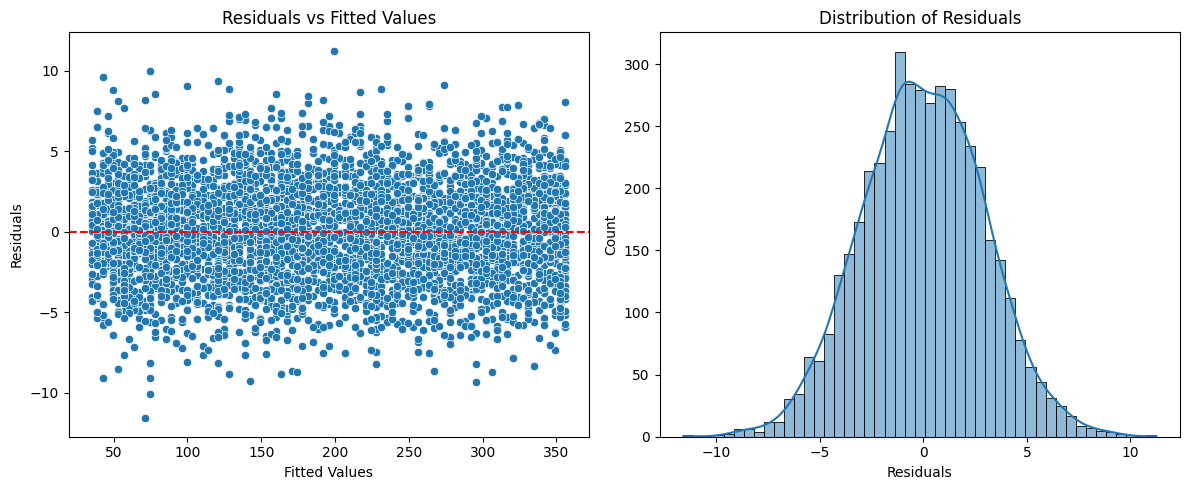

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract predictions and residuals
fitted_values = model.predict(X)
residuals = model.resid

# Create and configuration of diagnostic subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Homoscedasticity & Linearity check (Fitted vs Residuals)
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Plot 2: Normality Check (Histogram of Residuals)
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')

plt.tight_layout()
# Force the plots to render down the cell
plt.show()